<a href="https://colab.research.google.com/github/benram2004-lab/mis433/blob/main/ChurnAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

accounts     = pd.read_csv('/content/accounts.csv')
demographics = pd.read_csv('/content/demographics.csv')
services     = pd.read_csv('/content/services.csv')
churn_train  = pd.read_csv('/content/churn_train.csv')
churn_test   = pd.read_csv('/content/churn_test.csv')

In [10]:
#describe and summarize
print("=== SHAPES ===")
for name, df in [('accounts',accounts),('demographics',demographics),
                 ('services',services),('churn_train',churn_train),('churn_test',churn_test)]:
    print(f"{name}: {df.shape}")

print("\n=== ACCOUNTS SUMMARY ===")
print("--- Head ---")
display(accounts.head())
print("--- Describe ---")
display(accounts.describe(include='all'))
print("\n=== CHURN DISTRIBUTION ===")
print(churn_train['Churn'].value_counts())

=== SHAPES ===
accounts: (5298, 8)
demographics: (5298, 8)
services: (47682, 3)
churn_train: (4238, 2)
churn_test: (1060, 1)

=== ACCOUNTS SUMMARY ===
--- Head ---


,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


--- Describe ---


,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
count,5298.000000,5298.000000,5298,5288.000000,5298,5298,5293,5298
unique,NaN,NaN,1,NaN,73,2,3,4
top,NaN,NaN,5-1-2012,NaN,6-Dec-11,Yes,Month-to-month,Electronic check
freq,NaN,NaN,5298,NaN,423,3120,2779,1586
mean,3849.500000,325.467205,NaN,11928.354056,NaN,NaN,NaN,NaN
std,1529.545194,151.352954,NaN,11486.453199,NaN,NaN,NaN,NaN
min,1201.000000,91.250000,NaN,94.250000,NaN,NaN,NaN,NaN
25%,2525.250000,178.250000,NaN,2314.937500,NaN,NaN,NaN,NaN
50%,3849.500000,352.500000,NaN,7377.500000,NaN,NaN,NaN,NaN
75%,5173.750000,451.250000,NaN,19992.812500,NaN,NaN,NaN,NaN



=== CHURN DISTRIBUTION ===
Churn
0    3189
1    1049
Name: count, dtype: int64


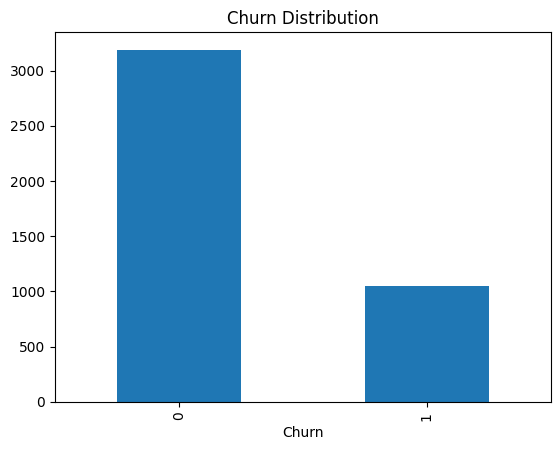

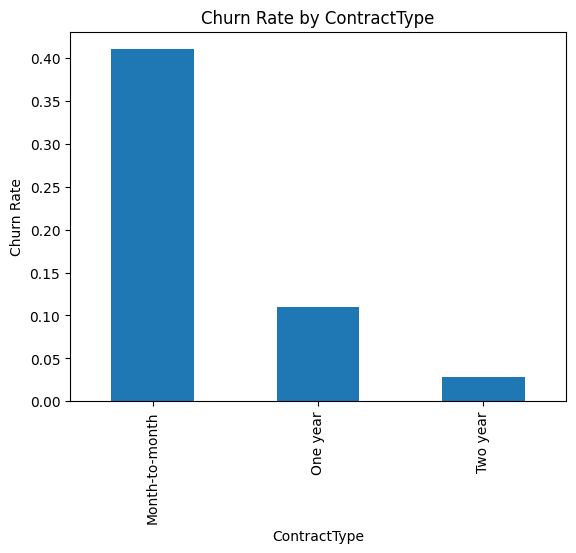

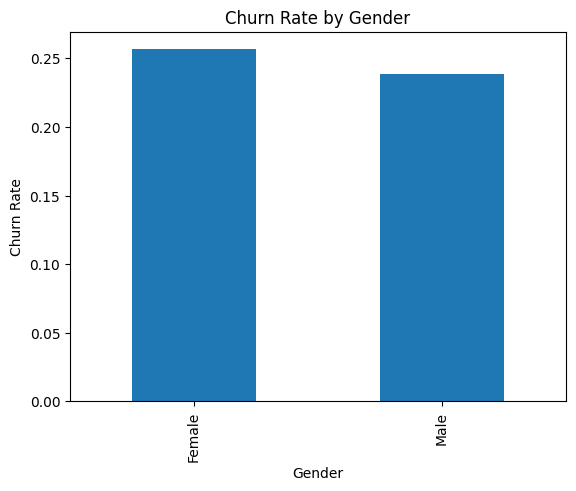

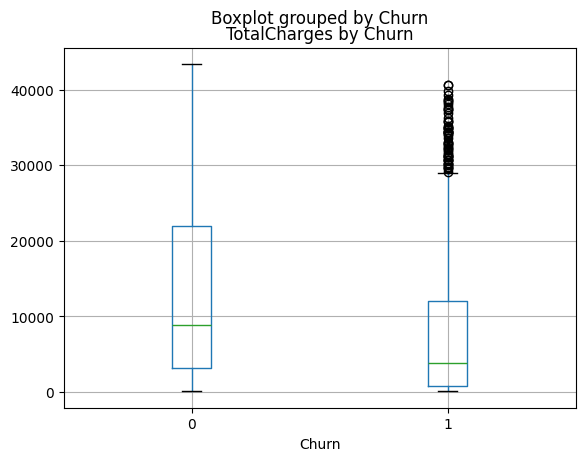

In [4]:
#visualizations
# Churn balance
churn_train['Churn'].value_counts().plot(kind='bar', title='Churn Distribution')
plt.show()

# Pivot services: count services per customer
svc_pivot = services.groupby(['CustomerNo','TypeOfService']).size().unstack(fill_value=0)
svc_pivot.columns = ['svc_' + c for c in svc_pivot.columns]

# Merge all into one flat table for EDA
merged = churn_train.merge(accounts, on='CustomerNo').merge(demographics, on='CustomerNo').merge(svc_pivot, on='CustomerNo', how='left')

# Churn by ContractType
merged.groupby('ContractType')['Churn'].mean().plot(kind='bar', title='Churn Rate by ContractType')
plt.ylabel('Churn Rate'); plt.show()

# Churn by Gender
merged.groupby('Gender')['Churn'].mean().plot(kind='bar', title='Churn Rate by Gender')
plt.ylabel('Churn Rate'); plt.show()

# TotalCharges distribution
merged['TotalCharges'] = pd.to_numeric(merged['TotalCharges'], errors='coerce')
merged.boxplot(column='TotalCharges', by='Churn')
plt.title('TotalCharges by Churn'); plt.show()

In [5]:
#preproccersing
def build_features(df, svc_pivot):
    df = df.merge(accounts, on='CustomerNo').merge(demographics, on='CustomerNo').merge(svc_pivot, on='CustomerNo', how='left')

    # Drop columns not useful for prediction
    df = df.drop(columns=['CustomerNo', 'DOC', 'DOE'], errors='ignore')

    # Convert TotalCharges to numeric
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Encode categoricals
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    # Fill NaNs
    df = df.fillna(0)
    return df

# Build features
train_feat = build_features(churn_train.copy(), svc_pivot)
X = train_feat.drop(columns=['Churn'])
y = train_feat['Churn']

test_feat = build_features(churn_test.copy(), svc_pivot)
X_test = test_feat

# Standardize
scaler = StandardScaler()
X_scaled     = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X.shape, "  Test shape:", X_test.shape)

Train shape: (4238, 21)   Test shape: (1060, 21)


In [6]:
#First model logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
print("Logistic Regression train score:", lr.score(X_scaled, y))
print(classification_report(y, lr.predict(X_scaled)))

Logistic Regression train score: 0.8072203869749882
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3189
           1       0.65      0.48      0.55      1049

    accuracy                           0.81      4238
   macro avg       0.75      0.70      0.71      4238
weighted avg       0.79      0.81      0.80      4238



In [7]:
#Second model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
print("Random Forest train score:", rf.score(X, y))
print(classification_report(y, rf.predict(X)))

Random Forest train score: 0.9988201982067013
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3189
           1       1.00      1.00      1.00      1049

    accuracy                           1.00      4238
   macro avg       1.00      1.00      1.00      4238
weighted avg       1.00      1.00      1.00      4238



In [8]:
#Third Model Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X, y)
print("Gradient Boosting train score:", gb.score(X, y))
print(classification_report(y, gb.predict(X)))

Gradient Boosting train score: 0.8421425200566305
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      3189
           1       0.74      0.57      0.64      1049

    accuracy                           0.84      4238
   macro avg       0.80      0.75      0.77      4238
weighted avg       0.83      0.84      0.83      4238



In [9]:
#prediction
# Use Gradient Boosting (usually best of the three)
preds = gb.predict(X_test)

submission = pd.DataFrame({
    'CustomerNo': churn_test['CustomerNo'],
    'Churn': preds
})
submission.to_csv('submission.csv', index=False)
print(submission['Churn'].value_counts())
display(submission.head())

Churn
0    864
1    196
Name: count, dtype: int64


,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [11]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>